# Feature Extraction Progress

| Feature | Domain | Implemented | Verified | Notes |
|---------|--------|:-----------:|:--------:|------|
| Mean | Time Domain | ✅ | ✅ | Average value of the waveform |
| Variance | Time Domain | ✅ | ✅ | Measures waveform fluctuations |
| RMS | Time Domain | ✅ | ✅ |Effective value of the waveform |
| Standard Deviation | Time Domain | ✅ | ✅ |Measures signal dispersion around the mean |
| Peak Value | Time Domain | ✅ | ✅ |Maximum amplitude of the waveform |
| Peak-to-Peak Value | Time Domain | ✅ | ✅ |Difference between the maximum and minimum amplitudes |
| Crest Factor | Time Domain | ✅ | ✅ |Measures the sharpness of waveform peaks |
| Skewness | Time Domain | ✅ | ✅ |Measures the asymmetry of the waveform distribution |
| Kurtosis | Time Domain | ✅ | ✅ |Measures the impulsiveness or peakedness of the waveform |
| FFT Energy | Frequency Domain | ⬜ | ⬜ | |
| Dominant Frequency | Frequency Domain | ⬜ | ⬜ | |
| Spectral Centroid | Frequency Domain | ⬜ | ⬜ | |
| High Frequency Energy | Frequency Domain | ⬜ | ⬜ | |

In [89]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

In [90]:
#load dataset
data =sio.loadmat("../data/dataset_2classes_20ms_100kHz.mat")

X_train = data["yTrain"]
X_test = data["yTest"]

y_train = data["labelsTrain"].ravel()
y_test = data["labelsTest"].ravel()

In [91]:
print("Training Signals :", X_train.shape)
print("Training Labels  :", y_train.shape)

print("Testing Signals  :", X_test.shape)
print("Testing Labels   :", y_test.shape)

Training Signals : (1334, 2000)
Training Labels  : (1334,)
Testing Signals  : (1334, 2000)
Testing Labels   : (1334,)


In [92]:
#create empty feature table
train_features=pd.DataFrame()
test_features=pd.DataFrame()

## Feature 1 - Mean

The mean is the average current value of one waveform.

Formula:

μ = (1/N) Σxi

In [93]:
train_features["Mean"] = np.mean(X_train, axis=1)
test_features["Mean"] = np.mean(X_test, axis=1)

In [94]:
train_features.head()
train_features.describe()


,Mean
count,1334.000000
mean,2.981505
std,2.696259
min,0.037542
25%,0.538074
50%,2.583004
75%,5.029362
max,22.455408


## Feature 2: Variance

### Definition
Variance is a time-domain statistical feature that measures how much the current samples in a waveform deviate from their mean value.

### Purpose
It quantifies the variability or fluctuation in the current waveform. A higher variance indicates greater fluctuations, while a lower variance indicates a more stable signal.

### Mathematical Formula
$$
\sigma^2=\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2
$$


where:

- $x_i$ = Current sample
- $\mu$ = Mean of the waveform
- $N$ = Number of samples (2000)


### Why is this feature used?

The review paper identifies **variance** as one of the time-domain features used for arc-fault detection. Variance helps quantify changes in the waveform caused by electrical arc faults, which often introduce irregular fluctuations into the current signal.

In [95]:
#variance feature
train_features["variance"]=np.var(X_train,axis=1)
test_features["variance"]=np.var(X_test,axis=1)


In [96]:
train_features.head()

,Mean,variance
0,0.533602,0.104965
1,0.540411,0.093205
2,0.458872,0.075319
3,0.380859,0.048815
4,0.379759,0.048610


In [97]:
train_features["variance"].describe()

count    1334.000000
mean        7.116362
std        13.818908
min         0.000423
25%         0.203942
50%         3.577023
75%         9.980389
max       285.899994
Name: variance, dtype: float64

In [98]:
#compare normal vs arc
normal_var=train_features[y_train==0]["variance"]
arc_var=train_features[y_train==1]["variance"]
print("Normal Mean Variance :", normal_var.mean())
print("Arc Mean Variance    :", arc_var.mean())

Normal Mean Variance : 7.909935
Arc Mean Variance    : 5.662321


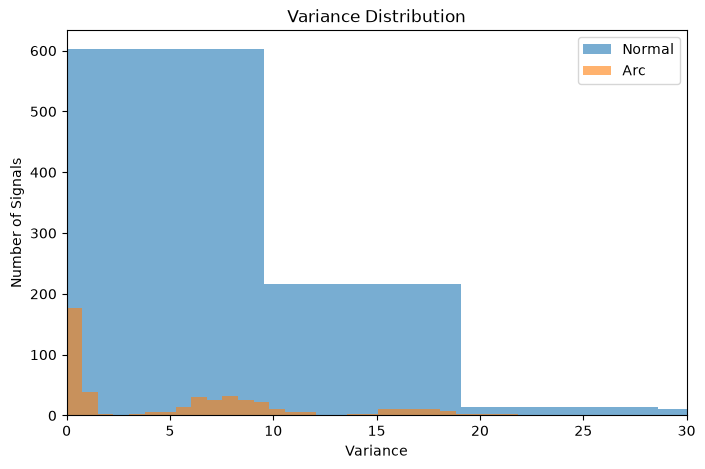

In [99]:
plt.figure(figsize=(8,5))

plt.hist(normal_var, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_var, bins=30, alpha=0.6, label="Arc")

plt.xlim(0, 30)   # Focus on the main region

plt.xlabel("Variance")
plt.ylabel("Number of Signals")
plt.title("Variance Distribution")
plt.legend()

plt.show()

**Observation: 
The variance distributions of normal and arc signals overlap considerably. Normal signals exhibit a wider spread and a slightly higher average variance than arc signals in this dataset. Therefore, variance alone is insufficient for classification but can contribute as part of a combined feature set.**

## Feature 3: Root Mean Square (RMS)

### Definition

Root Mean Square (RMS) is a time-domain feature that represents the effective value of the current waveform.

### Purpose

It measures the overall magnitude of the current signal regardless of its polarity. RMS is widely used in electrical engineering because it represents the equivalent DC value that would produce the same heating effect.

### Mathematical Formula

$$
RMS=\sqrt{\frac{1}{N}\sum_{i=1}^{N}x_i^2}
$$

where:

- $x_i$ = Current sample
- $N$ = Number of samples (2000)

### Why is this feature used?

RMS captures the overall energy level of the current waveform. Changes in the waveform caused by an arc fault may affect the RMS value, making it a useful feature for machine learning models.


In [100]:
#rms feature
train_features["RMS"]=np.sqrt(np.mean(X_train**2,axis=1))
test_features["RMS"]=np.sqrt(np.mean(X_test**2,axis=1))


In [101]:
train_features.head()

,Mean,variance,RMS
0,0.533602,0.104965,0.624256
1,0.540411,0.093205,0.620685
2,0.458872,0.075319,0.534680
3,0.380859,0.048815,0.440305
4,0.379759,0.048610,0.439121


In [102]:
test_features.head()

,Mean,variance,RMS
0,0.554625,0.097904,0.636799
1,0.514968,0.086472,0.593013
2,0.396390,0.055845,0.461487
3,0.379957,0.048933,0.439660
4,0.379420,0.048512,0.438715


In [103]:
train_features["RMS"].describe()

count    1334.000000
mean        3.638635
std         3.168272
min         0.044695
25%         0.749950
50%         2.869568
75%         6.098333
max        28.109529
Name: RMS, dtype: float64

In [104]:
#compare normal vs arc
normal_rms = train_features.loc[y_train == 0, "RMS"]
arc_rms = train_features.loc[y_train == 1, "RMS"]

print("Normal Mean RMS :", normal_rms.mean())
print("Arc Mean RMS    :", arc_rms.mean())

Normal Mean RMS : 3.9590454
Arc Mean RMS    : 3.0515556


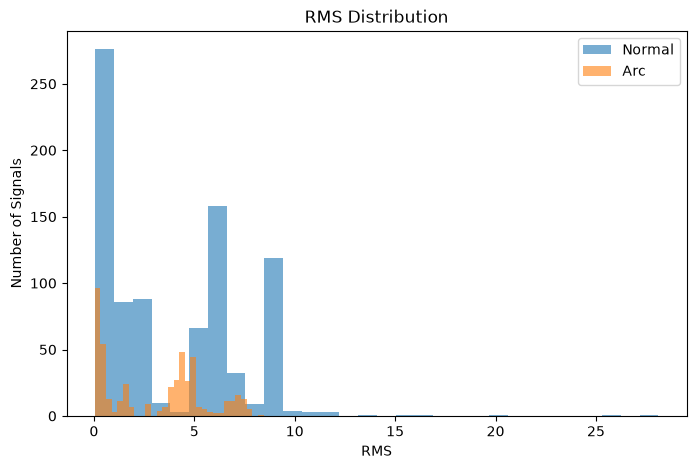

In [61]:
plt.figure(figsize=(8,5))

plt.hist(normal_rms, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_rms, bins=30, alpha=0.6, label="Arc")

plt.xlabel("RMS")
plt.ylabel("Number of Signals")
plt.title("RMS Distribution")
plt.legend()

plt.show()


### Observation

- The RMS distributions of normal and arc signals show considerable overlap.
- The average RMS of normal signals (3.959) is higher than that of arc signals (3.052) in this dataset.
- Normal signals exhibit a wider range of RMS values, while arc signals are concentrated within a lower RMS range.
- RMS alone is insufficient for distinguishing between normal and arc signals, but it can contribute as an informative feature when combined with other time-domain and frequency-domain features.

## Feature 4: Peak Value

### Definition

Peak Value is the maximum current value present in a waveform.

### Purpose

It represents the highest current amplitude reached during the signal. Electrical arc faults may produce sudden current spikes, making the peak value a useful feature for waveform characterization.

### Mathematical Formula

$$
Peak = \max(x_i)
$$

where:

- $x_i$ = Current sample
- $N$ = Number of samples (2000)

### Why is this feature used?

Peak Value captures the maximum current amplitude of a waveform. It helps identify sudden increases in current that may occur during an arc fault and provides complementary information to statistical features such as Mean, Variance, and RMS.

In [62]:
train_features["peak"]=np.max(X_train,axis=1)
test_features["peak"]=np.max(X_test,axis=1)

In [63]:
train_features.head()

,Mean,variance,RMS,peak
0,0.533602,0.104965,0.624256,1.170862
1,0.540411,0.093205,0.620685,0.994693
2,0.458872,0.075319,0.534680,0.862457
3,0.380859,0.048815,0.440305,0.698957
4,0.379759,0.048610,0.439121,0.695823


In [64]:
train_features.describe()

,Mean,variance,RMS,peak
count,1334.000000,1334.000000,1334.000000,1334.000000
mean,2.981505,7.116362,3.638635,6.813399
std,2.696259,13.818908,3.168272,5.291595
min,0.037542,0.000423,0.044695,0.108945
25%,0.538074,0.203942,0.749950,2.144097
50%,2.583004,3.577023,2.869568,7.408414
75%,5.029362,9.980389,6.098333,10.379677
max,22.455408,285.899994,28.109529,48.293598


In [65]:
normal_peak=train_features.loc[y_train==0,"peak"]
arc_peak=train_features.loc[y_train==1,"peak"]
print("normal mean peak :",normal_peak.mean())
print("Arc Mean Peak    :", arc_peak.mean())

normal mean peak : 6.5468817
Arc Mean Peak    : 7.3017306


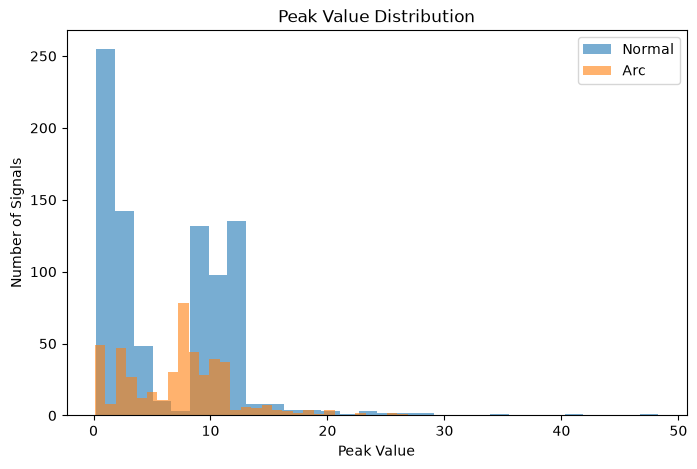

In [66]:
plt.figure(figsize=(8,5))

plt.hist(normal_peak, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_peak, bins=30, alpha=0.6, label="Arc")

plt.xlabel("Peak Value")
plt.ylabel("Number of Signals")
plt.title("Peak Value Distribution")
plt.legend()

plt.show()

### Observation

- The average Peak Value of arc signals (7.302) is higher than that of normal signals (6.547) in this dataset.
- Arc signals generally exhibit higher maximum current amplitudes, indicating the presence of sudden current spikes.
- The distributions of normal and arc signals still overlap, indicating that Peak Value alone is insufficient for reliable classification.
- Peak Value provides complementary information to Mean, Variance, and RMS, making it a useful feature for the Random Forest model.

## Feature 5: Peak-to-Peak Value (P2P)

### Definition

Peak-to-Peak (P2P) Value is a time-domain feature that represents the difference between the maximum and minimum current values in a waveform.

### Purpose

It measures the total amplitude range of the current signal. A larger Peak-to-Peak value indicates greater variation in the waveform amplitude.

### Mathematical Formula

$$
P2P = \max(x_i) - \min(x_i)
$$

where:

- $x_i$ = Current sample
- $N$ = Number of samples (2000)

### Why is this feature used?

Peak-to-Peak Value captures the overall amplitude range of the waveform. Since arc faults can alter the current waveform by introducing sudden peaks or dips, this feature provides additional information beyond Mean, Variance, RMS, and Peak Value.


In [67]:
train_features["peak_to_peak"]=np.ptp(X_train,axis=1)
test_features["peak_to_peak"]=np.ptp(X_test,axis=1)

In [68]:
train_features.head()

,Mean,variance,RMS,peak,peak_to_peak
0,0.533602,0.104965,0.624256,1.170862,1.170465
1,0.540411,0.093205,0.620685,0.994693,0.994289
2,0.458872,0.075319,0.534680,0.862457,0.861772
3,0.380859,0.048815,0.440305,0.698957,0.698934
4,0.379759,0.048610,0.439121,0.695823,0.695626


In [69]:
train_features["peak_to_peak"].describe()


count    1334.000000
mean        6.787882
std         5.295669
min         0.108901
25%         2.059374
50%         7.407991
75%        10.379364
max        48.291485
Name: peak_to_peak, dtype: float64

In [70]:
normal_p2p = train_features.loc[y_train == 0, "peak_to_peak"]
arc_p2p = train_features.loc[y_train == 1, "peak_to_peak"]

print("Normal Mean P2P :", normal_p2p.mean())
print("Arc Mean P2P    :", arc_p2p.mean())

Normal Mean P2P : 6.5333843
Arc Mean P2P    : 7.2541914


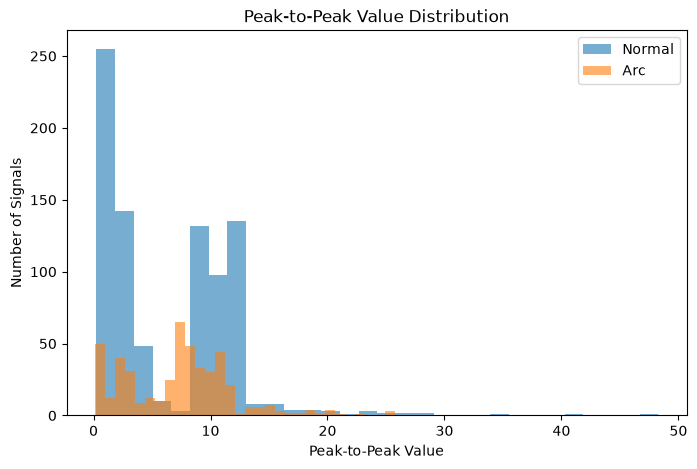

In [71]:
plt.figure(figsize=(8,5))

plt.hist(normal_p2p, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_p2p, bins=30, alpha=0.6, label="Arc")

plt.xlabel("Peak-to-Peak Value")
plt.ylabel("Number of Signals")
plt.title("Peak-to-Peak Value Distribution")
plt.legend()

plt.show()

### Observation

- The average Peak-to-Peak value of arc signals (7.254) is higher than that of normal signals (6.533) in this dataset.
- Arc signals generally exhibit a larger amplitude range than normal signals.
- The Peak-to-Peak distributions of normal and arc signals overlap considerably, indicating that this feature alone cannot reliably distinguish between the two classes.
- Peak-to-Peak Value provides complementary information about the waveform's amplitude range and can improve classification performance when combined with other extracted features.

## Feature 6: Crest Factor

### Definition

Crest Factor is a time-domain feature that represents the ratio of the peak value to the RMS value of a waveform.

### Purpose

It indicates how large the highest peak is compared to the effective value of the signal. Signals with sharp transient spikes generally have a higher Crest Factor.

### Mathematical Formula

$$
\text{Crest Factor}=\frac{\text{Peak Value}}{\text{RMS}}
$$

where:

- Peak Value = Maximum current of the waveform
- RMS = Root Mean Square value of the waveform

### Why is this feature used?

Crest Factor helps identify impulsive or spiky waveforms. Since electrical arc faults often introduce sudden current spikes, Crest Factor can provide useful information for distinguishing arc-fault signals from normal operating signals.

In [72]:
train_features["Crest_Factor"]=(train_features["peak"]/train_features["RMS"])
test_features["Crest_Factor"]=(test_features["peak"]/test_features["RMS"])

In [73]:
train_features.head()

,Mean,variance,RMS,peak,peak_to_peak,Crest_Factor
0,0.533602,0.104965,0.624256,1.170862,1.170465,1.875612
1,0.540411,0.093205,0.620685,0.994693,0.994289,1.602574
2,0.458872,0.075319,0.534680,0.862457,0.861772,1.613033
3,0.380859,0.048815,0.440305,0.698957,0.698934,1.587438
4,0.379759,0.048610,0.439121,0.695823,0.695626,1.584581


In [74]:
train_features["Crest_Factor"].describe()

count    1334.000000
mean        3.198624
std         4.720415
min         1.183334
25%         1.584729
50%         1.801787
75%         2.157626
max        35.298950
Name: Crest_Factor, dtype: float64

In [75]:
normal_cf = train_features.loc[y_train == 0, "Crest_Factor"]
arc_cf = train_features.loc[y_train == 1, "Crest_Factor"]

print("Normal Mean Crest Factor :", normal_cf.mean())
print("Arc Mean Crest Factor    :", arc_cf.mean())

Normal Mean Crest Factor : 1.8526332
Arc Mean Crest Factor    : 5.6648436


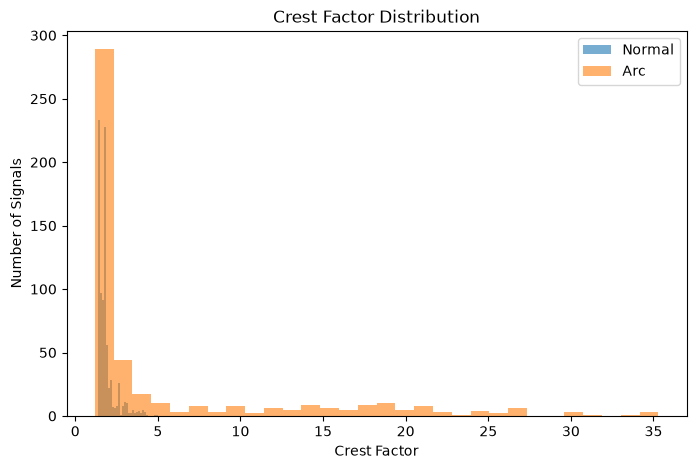

In [76]:
plt.figure(figsize=(8, 5))

plt.hist(normal_cf, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_cf, bins=30, alpha=0.6, label="Arc")

plt.xlabel("Crest Factor")
plt.ylabel("Number of Signals")
plt.title("Crest Factor Distribution")
plt.legend()

plt.show()

### Observation

- The average Crest Factor of arc signals (5.665) is significantly higher than that of normal signals (1.853).
- Normal signals are concentrated within a lower Crest Factor range, whereas arc signals exhibit a much wider distribution with higher values.
- Crest Factor provides better separation between normal and arc signals than the previously extracted statistical features.
- The higher Crest Factor of arc signals indicates the presence of sharp transient current spikes, making it a highly informative feature for Random Forest classification.

## Feature 7: Kurtosis

### Definition

Kurtosis is a time-domain statistical feature that measures the sharpness or peakedness of a waveform distribution.

### Purpose

It quantifies the presence of sharp peaks or impulsive events in a signal. Signals containing sudden spikes generally have higher kurtosis values.

### Mathematical Formula

$$
\text{Kurtosis} =
\frac{\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^4}
{\left(\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2\right)^2}
$$

where:

- $x_i$ = Current sample
- $\mu$ = Mean of the waveform
- $N$ = Number of samples (2000)

### Why is this feature used?

Kurtosis is sensitive to impulsive events and sharp peaks in the waveform. Since electrical arc faults often generate transient spikes, kurtosis is a useful feature for distinguishing arc-fault signals from normal operating signals.

In [77]:
from scipy.stats import kurtosis

In [78]:
# Kurtosis Feature

train_features["Kurtosis"] = kurtosis(X_train, axis=1)
test_features["Kurtosis"] = kurtosis(X_test, axis=1)

In [79]:
train_features.head()

,Mean,variance,RMS,peak,peak_to_peak,Crest_Factor,Kurtosis
0,0.533602,0.104965,0.624256,1.170862,1.170465,1.875612,-0.830772
1,0.540411,0.093205,0.620685,0.994693,0.994289,1.602574,-1.379930
2,0.458872,0.075319,0.534680,0.862457,0.861772,1.613033,-1.401482
3,0.380859,0.048815,0.440305,0.698957,0.698934,1.587438,-1.346339
4,0.379759,0.048610,0.439121,0.695823,0.695626,1.584581,-1.348572


In [80]:
train_features["Kurtosis"].describe()

count    1334.000000
mean       15.375126
std        82.985153
min        -1.809251
25%        -1.448586
50%        -1.115485
75%        -0.866986
max      1058.202271
Name: Kurtosis, dtype: float64

In [81]:
normal_kurt = train_features.loc[y_train == 0, "Kurtosis"]
arc_kurt = train_features.loc[y_train == 1, "Kurtosis"]

print("Normal Mean Kurtosis :", normal_kurt.mean())
print("Arc Mean Kurtosis    :", arc_kurt.mean())

Normal Mean Kurtosis : -0.7368608
Arc Mean Kurtosis    : 44.896664


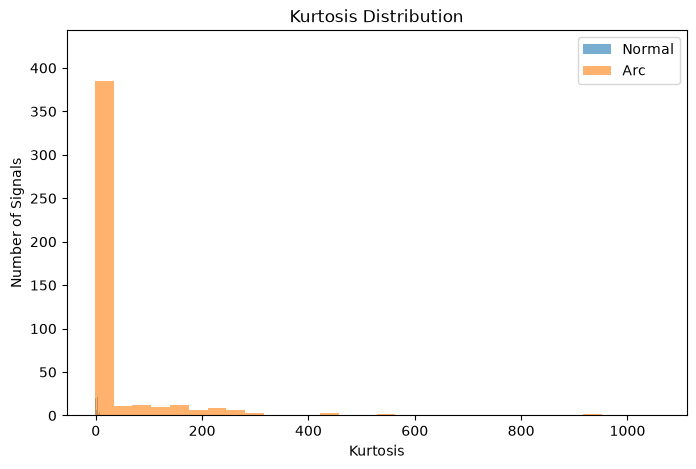

In [82]:
plt.figure(figsize=(8,5))

plt.hist(normal_kurt, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_kurt, bins=30, alpha=0.6, label="Arc")

plt.xlabel("Kurtosis")
plt.ylabel("Number of Signals")
plt.title("Kurtosis Distribution")
plt.legend()

plt.show()

### Observation

- The average kurtosis of arc signals (44.897) is significantly higher than that of normal signals (-0.737).
- Normal signals are concentrated around low kurtosis values, whereas arc signals exhibit a much wider distribution with several extremely high values.
- The high kurtosis values of arc signals indicate the presence of impulsive current spikes within the waveform.
- Kurtosis provides strong discrimination between normal and arc signals, making it one of the most informative time-domain features for Random Forest classification.

## Feature 8: Skewness

### Definition

Skewness is a time-domain statistical feature that measures the asymmetry of the waveform distribution around its mean.

### Purpose

It indicates whether the waveform is skewed towards higher or lower values. Changes in waveform symmetry caused by electrical arc faults may influence the skewness value.

### Mathematical Formula

$$
\text{Skewness} =
\frac{\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^3}
{\sigma^3}
$$

where:

- $x_i$ = Current sample
- $\mu$ = Mean of the waveform
- $\sigma$ = Standard deviation
- $N$ = Number of samples (2000)

### Why is this feature used?

Skewness measures the asymmetry of the waveform distribution. It provides additional statistical information that complements features such as Mean, Variance, RMS, Crest Factor, and Kurtosis.

In [83]:
from scipy.stats import skew
# Skewness Feature

train_features["Skewness"] = skew(X_train, axis=1)
test_features["Skewness"] = skew(X_test, axis=1)

In [84]:
train_features.head()

,Mean,variance,RMS,peak,peak_to_peak,Crest_Factor,Kurtosis,Skewness
0,0.533602,0.104965,0.624256,1.170862,1.170465,1.875612,-0.830772,0.361546
1,0.540411,0.093205,0.620685,0.994693,0.994289,1.602574,-1.379930,-0.129273
2,0.458872,0.075319,0.534680,0.862457,0.861772,1.613033,-1.401482,-0.073631
3,0.380859,0.048815,0.440305,0.698957,0.698934,1.587438,-1.346339,-0.123015
4,0.379759,0.048610,0.439121,0.695823,0.695626,1.584581,-1.348572,-0.121044


In [85]:
train_features["Skewness"].describe()

count    1334.000000
mean        1.044371
std         3.339688
min        -0.581143
25%        -0.162446
50%         0.222577
75%         0.593436
max        28.381809
Name: Skewness, dtype: float64

In [86]:
normal_skew = train_features.loc[y_train == 0, "Skewness"]
arc_skew = train_features.loc[y_train == 1, "Skewness"]

print("Normal Mean Skewness :", normal_skew.mean())
print("Arc Mean Skewness    :", arc_skew.mean())


Normal Mean Skewness : 0.17447393
Arc Mean Skewness    : 2.6382592


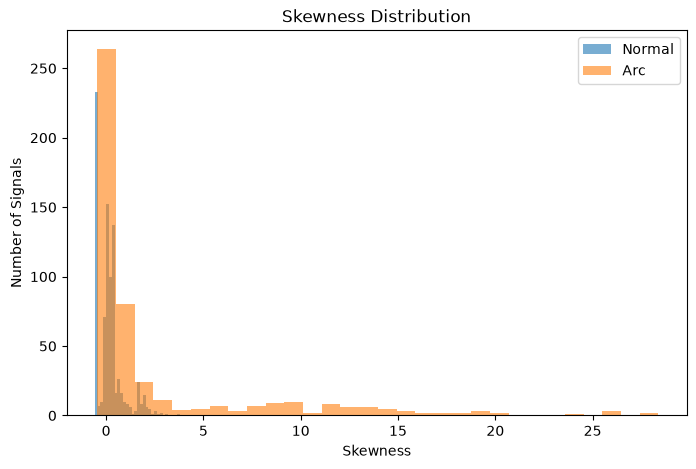

In [87]:
plt.figure(figsize=(8, 5))

plt.hist(normal_skew, bins=30, alpha=0.6, label="Normal")
plt.hist(arc_skew, bins=30, alpha=0.6, label="Arc")

plt.xlabel("Skewness")
plt.ylabel("Number of Signals")
plt.title("Skewness Distribution")
plt.legend()

plt.show()

### Observation

- The average skewness of arc signals (2.638) is considerably higher than that of normal signals (0.174).
- Normal signals are concentrated around values close to zero, whereas arc signals exhibit a wider distribution with higher positive skewness.
- The higher skewness of arc signals indicates increased waveform asymmetry caused by transient current spikes.
- Skewness provides useful statistical information that complements the other extracted time-domain features and can improve Random Forest classification when used in combination.

In [88]:
#feature table saving
train_features.to_csv("../data/train_features.csv", index=False)
test_features.to_csv("../data/test_features.csv", index=False)

print("Feature tables saved successfully!")


Feature tables saved successfully!
